# 02 · Matrix-Form Forward Pass

**Goal:** turn "a neuron computes a weighted sum" into one clean matrix expression that processes a whole batch at once.

For layer $l$ (row-major batch convention):

$$Z^{[l]} = A^{[l-1]}\,W^{[l]} + b^{[l]},\qquad A^{[l]} = g^{[l]}\!\left(Z^{[l]}\right),\qquad A^{[0]}=X$$

Shapes: $A^{[l-1]}\in\mathbb{R}^{N\times n_{l-1}}$, $W^{[l]}\in\mathbb{R}^{n_{l-1}\times n_l}$, $b^{[l]}\in\mathbb{R}^{n_l}$ (broadcast over rows), $Z^{[l]},A^{[l]}\in\mathbb{R}^{N\times n_l}$.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)

## 1. One neuron: loop vs dot product

In [2]:
x = np.array([1.0, 0.5, -1.0])
w = np.array([0.2, -0.4, 0.1])
b = 0.3

z_loop = 0.0
for i in range(len(x)):
    z_loop += w[i] * x[i]
z_loop += b

z_vec = x @ w + b
print("loop:", z_loop, " dot-product:", z_vec)

loop: 0.19999999999999998  dot-product: 0.19999999999999998


## 2. Activation functions
Without a non-linearity, stacking layers collapses into a single linear map ($W_2(W_1x)=(W_2W_1)x$). The activation is what gives depth its power.

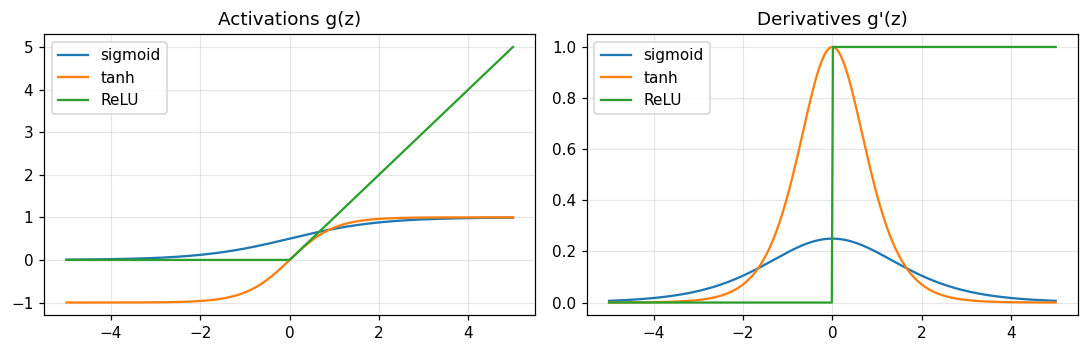

In [3]:
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))
def tanh(z):    return np.tanh(z)
def relu(z):    return np.maximum(0.0, z)

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)      # subtract row max: numerically stable
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

zs = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
for name, f in [("sigmoid", sigmoid), ("tanh", tanh), ("ReLU", relu)]:
    ax[0].plot(zs, f(zs), label=name)
ax[0].set_title("Activations g(z)"); ax[0].legend(); ax[0].grid(alpha=.3)

h = 1e-5
for name, f in [("sigmoid", sigmoid), ("tanh", tanh), ("ReLU", relu)]:
    ax[1].plot(zs, (f(zs + h) - f(zs - h)) / (2 * h), label=name)
ax[1].set_title("Derivatives g'(z)"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. A whole layer on a whole batch

In [4]:
def dense(A_prev, W, b):
    return A_prev @ W + b

N, d, h = 5, 4, 3
X = rng.normal(size=(N, d))
W = rng.normal(size=(d, h))
b = rng.normal(size=(h,))

Z = dense(X, W, b)
print(f"X{X.shape} @ W{W.shape} + b{b.shape}  ->  Z{Z.shape}")

X(5, 4) @ W(4, 3) + b(3,)  ->  Z(5, 3)


### Loop version vs matrix version
Same numbers, wildly different speed. The matrix form hands the work to optimised BLAS routines (and, later, to GPUs).

In [5]:
def dense_loops(X, W, b):
    N, d = X.shape
    h = W.shape[1]
    Z = np.zeros((N, h))
    for n in range(N):             # every sample
        for j in range(h):         # every neuron
            s = 0.0
            for i in range(d):     # every input
                s += X[n, i] * W[i, j]
            Z[n, j] = s + b[j]
    return Z

assert np.allclose(dense_loops(X, W, b), Z)

Xb = rng.normal(size=(32, 256)); Wb = rng.normal(size=(256, 64)); bb = np.zeros(64)
t0 = time.perf_counter(); Zl = dense_loops(Xb, Wb, bb); t_loop = time.perf_counter() - t0
t0 = time.perf_counter(); Zm = dense(Xb, Wb, bb);       t_mat = time.perf_counter() - t0
assert np.allclose(Zl, Zm)
print(f"loops: {t_loop*1e3:8.2f} ms | matrix: {t_mat*1e3:8.3f} ms | speed-up ~ {t_loop / t_mat:,.0f}x")

loops:   208.38 ms | matrix:    0.128 ms | speed-up ~ 1,630x


## 4. Full network forward pass (with a cache for backprop)
We keep every $Z^{[l]}$ and $A^{[l]}$ – backpropagation in the next notebooks needs them.

In [6]:
def init_params(sizes, rng):
    """He initialisation: Var(W) = 2 / fan_in (suits ReLU)."""
    return [(rng.normal(0, np.sqrt(2.0 / i), (i, o)), np.zeros(o))
            for i, o in zip(sizes[:-1], sizes[1:])]

def forward(X, params, verbose=False):
    A, L = X, len(params)
    cache = [(None, X)]                       # cache[l] = (Z^[l], A^[l])
    for l, (W, b) in enumerate(params, start=1):
        Z = A @ W + b
        A_new = softmax(Z) if l == L else relu(Z)
        if verbose:
            kind = "softmax" if l == L else "ReLU"
            print(f"layer {l}: A{A.shape} @ W{W.shape} + b{b.shape} -> Z{Z.shape} --{kind}--> A{A_new.shape}")
        A = A_new
        cache.append((Z, A))
    return A, cache

sizes = [784, 128, 64, 10]
params = init_params(sizes, rng)
X = rng.normal(size=(32, 784))
P, cache = forward(X, params, verbose=True)

print("\nrow sums of output:", np.round(P.sum(axis=1)[:5], 6), "...")
assert np.allclose(P.sum(axis=1), 1.0)

layer 1: A(32, 784) @ W(784, 128) + b(128,) -> Z(32, 128) --ReLU--> A(32, 128)
layer 2: A(32, 128) @ W(128, 64) + b(64,) -> Z(32, 64) --ReLU--> A(32, 64)
layer 3: A(32, 64) @ W(64, 10) + b(10,) -> Z(32, 10) --softmax--> A(32, 10)

row sums of output: [1. 1. 1. 1. 1.] ...


## 5. Numerical stability of softmax

In [7]:
z = np.array([[1000.0, 1001.0, 1002.0]])
with np.errstate(all="ignore"):
    naive = np.exp(z) / np.exp(z).sum(axis=1, keepdims=True)
print("naive softmax :", naive)
print("stable softmax:", softmax(z))

naive softmax : [[nan nan nan]]
stable softmax: [[0.09003057 0.24472847 0.66524096]]


## 6. A worked 2-2-1 example you can verify with pen and paper
$x=[1,\,0.5]$, $W^{[1]}=\begin{bmatrix}0.2&-0.3\\0.4&0.1\end{bmatrix}$, $b^{[1]}=[0.1,\,-0.1]$, ReLU, then $W^{[2]}=\begin{bmatrix}0.6\\-0.2\end{bmatrix}$, $b^{[2]}=0.05$, sigmoid.

* $z^{[1]} = [1\cdot0.2+0.5\cdot0.4+0.1,\; 1\cdot(-0.3)+0.5\cdot0.1-0.1] = [0.5,\,-0.35]$
* $a^{[1]} = [0.5,\,0]$
* $z^{[2]} = 0.5\cdot0.6 + 0\cdot(-0.2) + 0.05 = 0.35$, $\;\hat y=\sigma(0.35)\approx0.5866$

In [8]:
x  = np.array([[1.0, 0.5]])
W1 = np.array([[0.2, -0.3], [0.4, 0.1]]); b1 = np.array([0.1, -0.1])
W2 = np.array([[0.6], [-0.2]]);           b2 = np.array([0.05])

Z1 = x @ W1 + b1;  A1 = relu(Z1)
Z2 = A1 @ W2 + b2; A2 = sigmoid(Z2)
print("Z1 =", Z1, " A1 =", A1)
print("Z2 =", Z2, " y_hat =", A2)
assert np.allclose(Z1, [[0.5, -0.35]]) and np.allclose(Z2, [[0.35]])

Z1 = [[ 0.5  -0.35]]  A1 = [[0.5 0. ]]
Z2 = [[0.35]]  y_hat = [[0.58661758]]


### Try it yourself
1. Change the hidden activation to `tanh` and recompute by hand.
2. Pass a batch of 1000 samples through `forward` – which dimension changes? Which one never does?
3. Replace the loop in `dense_loops` by a single `for n in range(N)` using `X[n] @ W + b` and time it.